In [1]:
import sys
!{sys.executable} -m pip install xgboost
!{sys.executable} -m pip install lightgbm


[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: C:\Users\rasika\AppData\Local\Programs\Python\Python313\python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: C:\Users\rasika\AppData\Local\Programs\Python\Python313\python.exe -m pip install --upgrade pip


In [2]:
# importing libraries
import pandas as pd # reading csv files, data handling
import numpy as np # performs mathematical operations
import matplotlib.pyplot as plt # for graphical visualization
import seaborn as sns # for statistical visualization
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, StandardScaler # feature scaing 
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score # splitting dataset and hyper tunning
from xgboost import XGBClassifier # Boosting algorithm for model building
from lightgbm import LGBMClassifier # Boosting algorithm for model building
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score # model evaluation

In [3]:
# Loading the dataset 
df = pd.read_csv(r"C:\Users\rasika\Downloads\diabetes.csv")
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [4]:
# Summary of dataset
df.info() # shows number of entries of data, number of columns and their datatypes in dataset

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [5]:
# Summary Statistics
df.describe() # mean, standard deviation, min, max, count, quartiles of features in dataset

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [6]:
# chesking for missing values
(df[['Pregnancies', 'Glucose', 'BloodPressure',	'SkinThickness', 'Insulin',	'BMI',	'DiabetesPedigreeFunction',	'Age']] == 0).sum()

Pregnancies                 111
Glucose                       5
BloodPressure                35
SkinThickness               227
Insulin                     374
BMI                          11
DiabetesPedigreeFunction      0
Age                           0
dtype: int64

#### 0's in feature 'Pregnancies' is valid because there is probability that woman is not pregnant but remaining features getting 0 means it is null or missing value so it need to be handle and features 'Age' and 'DiabetesPedigreeFunction' having no null values so there is no necessary to handle them

### Histogram for frequency distribution of numerical features and skewness

array([[<Axes: title={'center': 'Pregnancies'}>,
        <Axes: title={'center': 'Glucose'}>,
        <Axes: title={'center': 'BloodPressure'}>],
       [<Axes: title={'center': 'SkinThickness'}>,
        <Axes: title={'center': 'Insulin'}>,
        <Axes: title={'center': 'BMI'}>],
       [<Axes: title={'center': 'DiabetesPedigreeFunction'}>,
        <Axes: title={'center': 'Age'}>,
        <Axes: title={'center': 'Outcome'}>]], dtype=object)

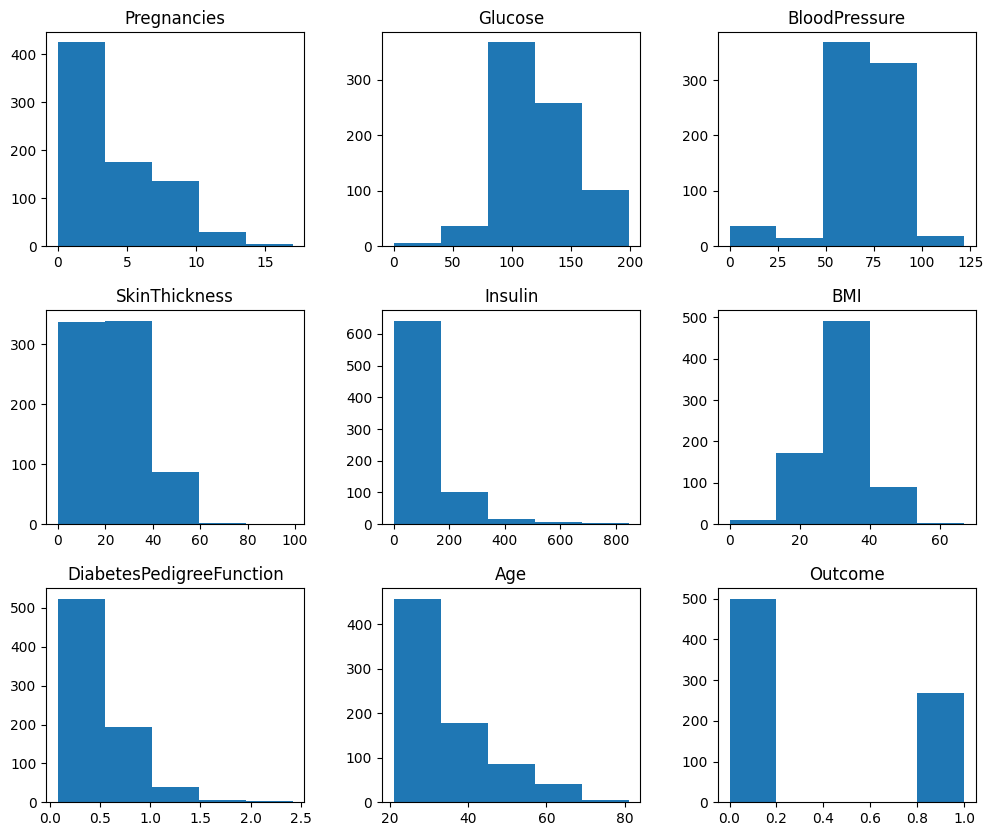

In [7]:
df.hist(bins = 5, grid = False, figsize = (12, 10))

1. Pregnancies, skinthickness, Insulin, DiabetesPedigreeFunction, Age are positively skewed.
2. Glucose aand BMI are slightly bell curved.
3. SkinThickness has very mmuch data distributed across 0.
4. In Outcome People with no diabetes are appeared more than non-diabetic ones.

### Bar chart to show frequarncy distribution 

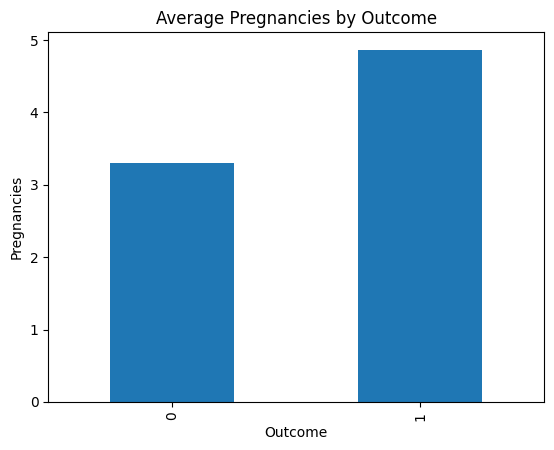

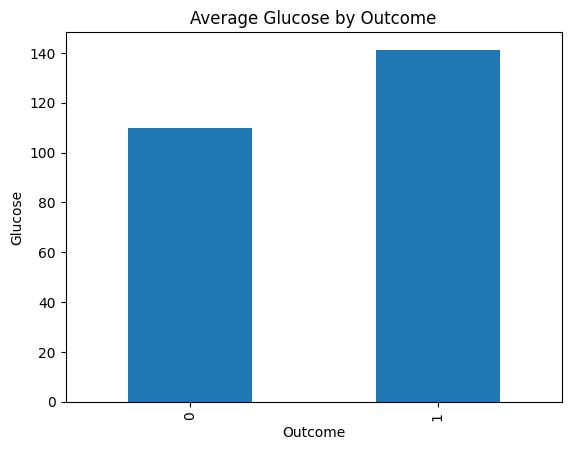

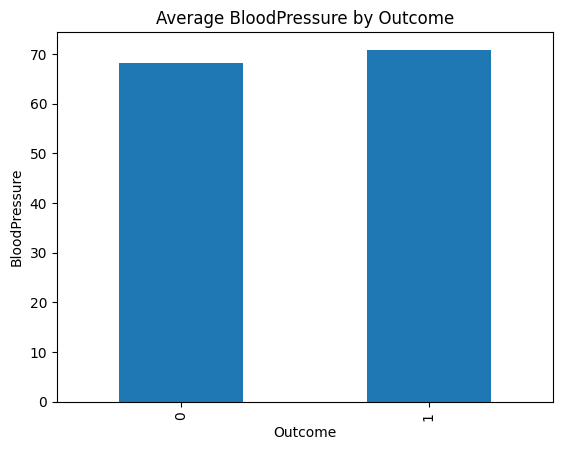

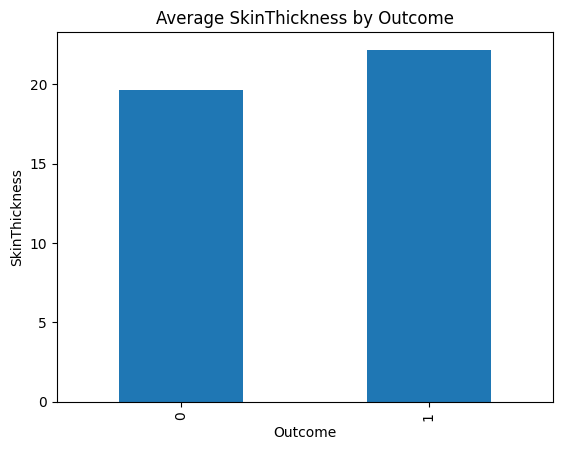

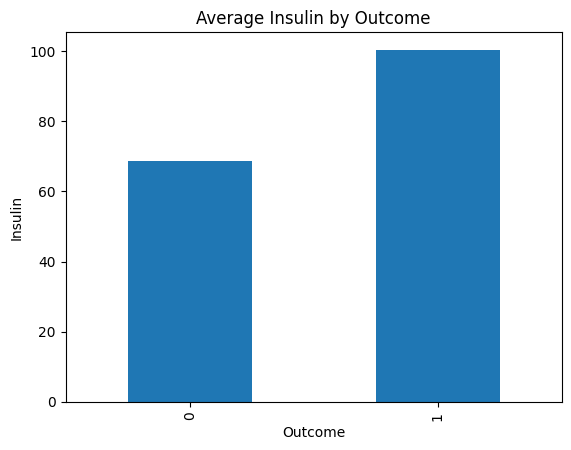

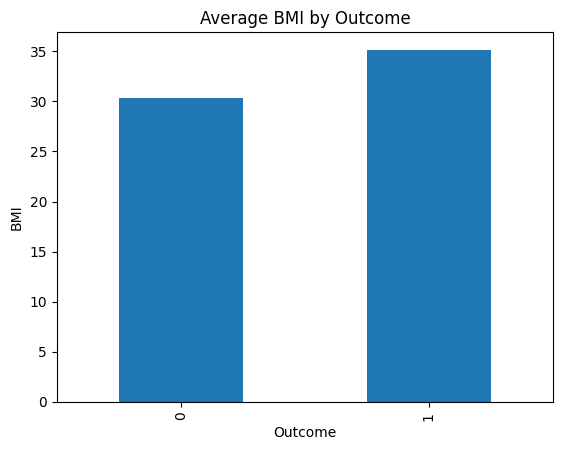

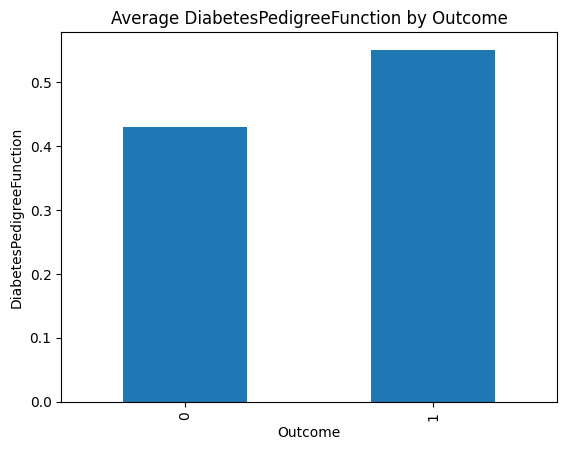

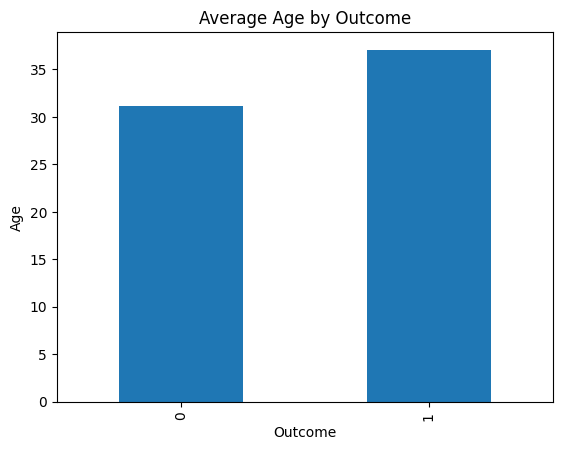

In [8]:
X = df.drop('Outcome', axis = 1)
for column in X.columns:
    df.groupby('Outcome')[column].mean().plot(kind='bar')
    plt.title(f'Average {column} by Outcome')
    plt.ylabel(column)
    plt.show()

### Scatter plot to show relationship among features with Target column

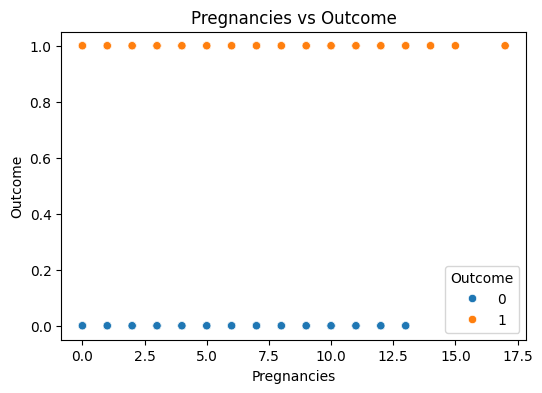

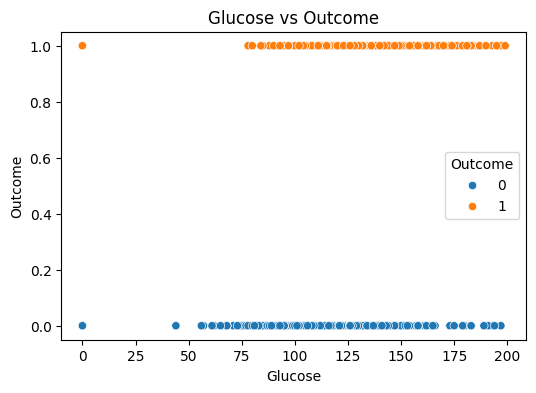

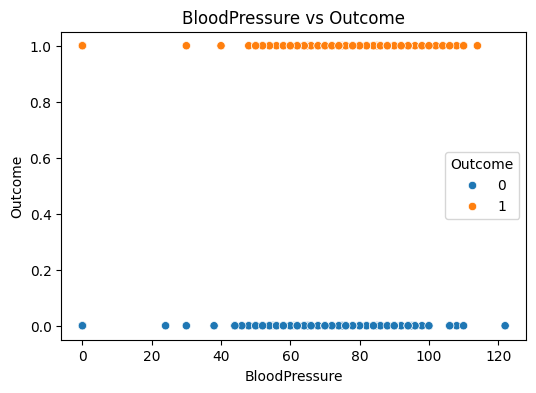

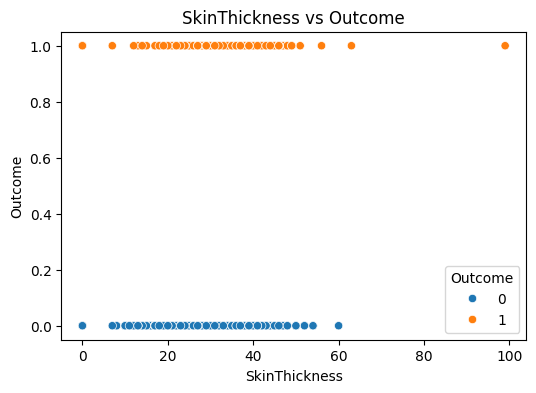

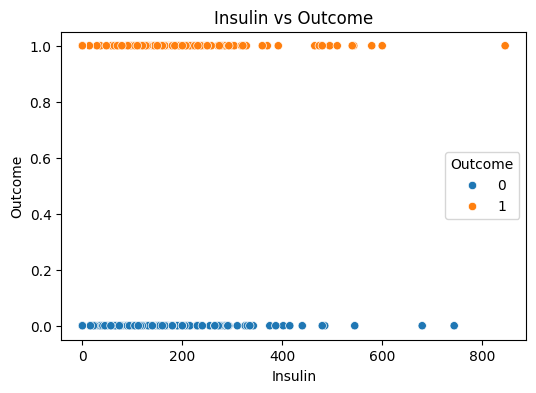

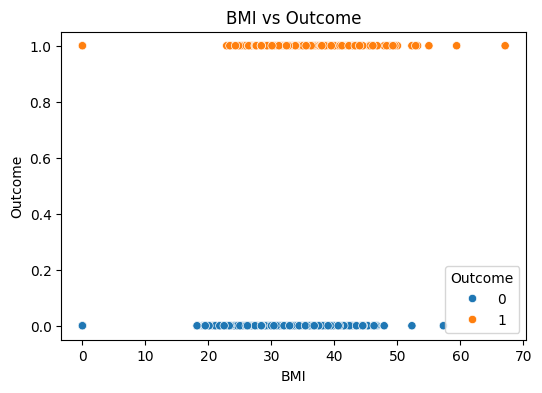

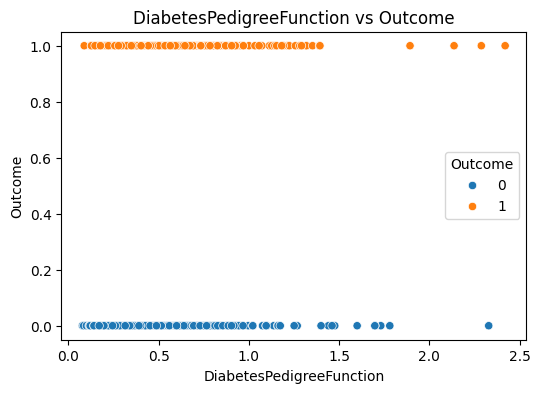

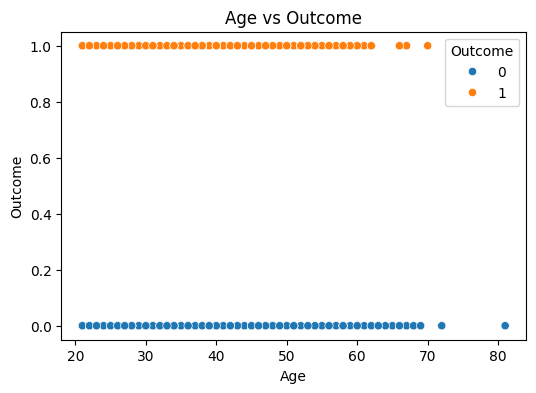

In [9]:
import seaborn as sns
import matplotlib.pyplot as plt

for column in X.columns:
    plt.figure(figsize=(6,4))
    sns.scatterplot(
        data=df,
        x=column,
        y='Outcome',
        hue='Outcome'
    )
    plt.title(f'{column} vs Outcome')
    plt.show()

### Heatmap to show correlation among features

<Axes: >

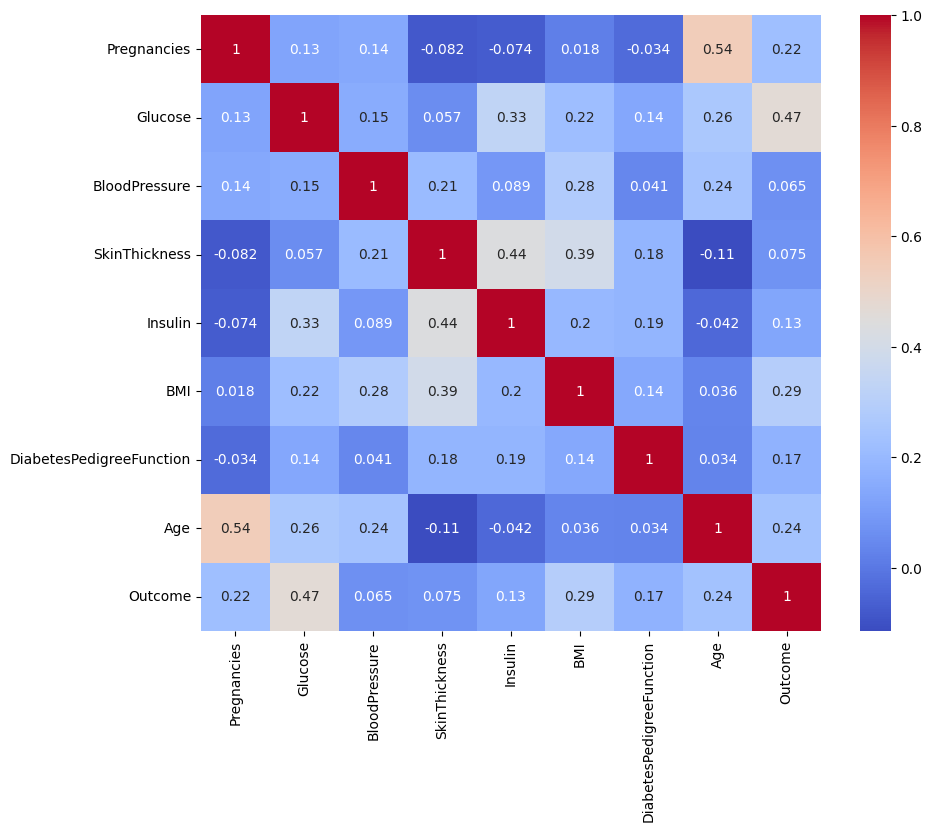

In [10]:
plt.figure(figsize = (10, 8))
sns.heatmap(df.corr(), annot = True, cmap = "coolwarm")

#### No features are correlated with each other

### Box plot Outlier Detection

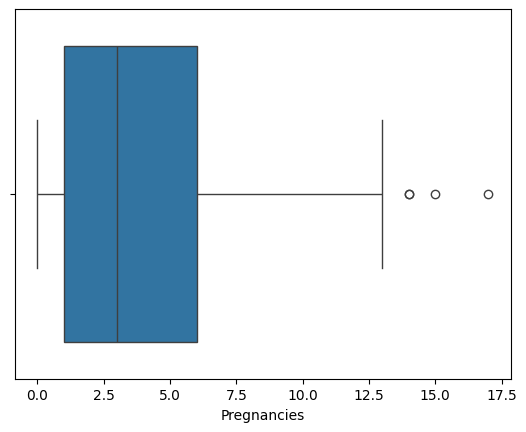

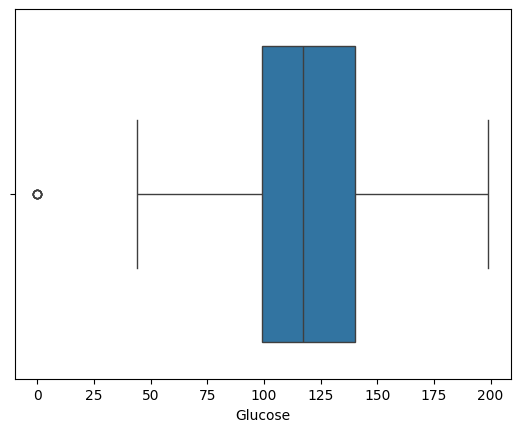

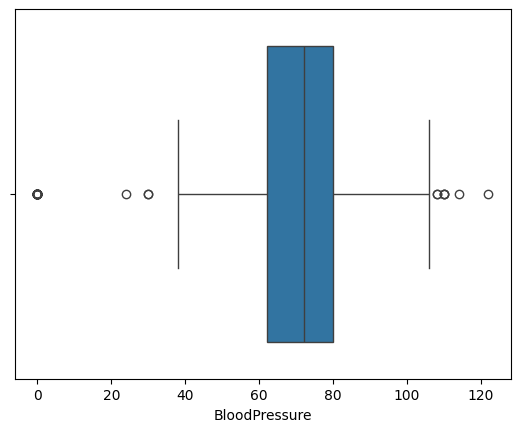

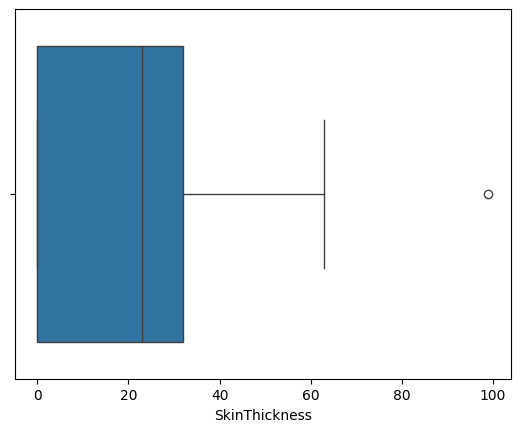

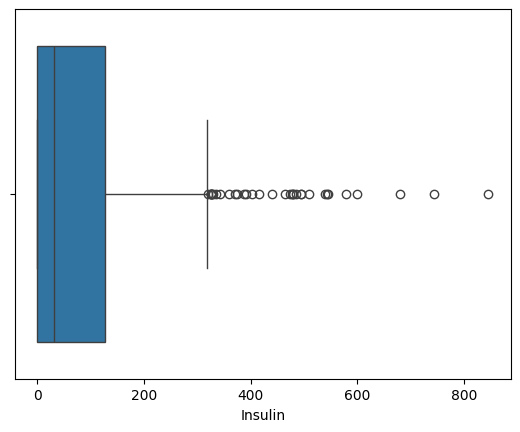

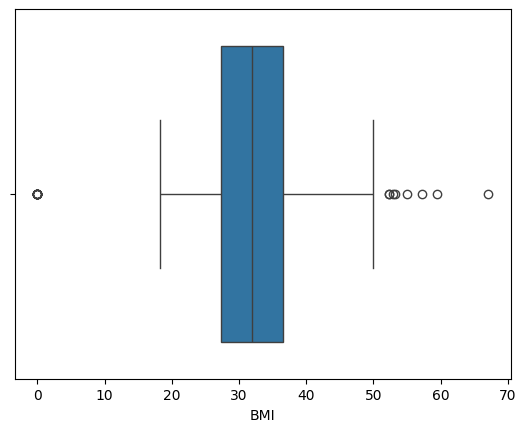

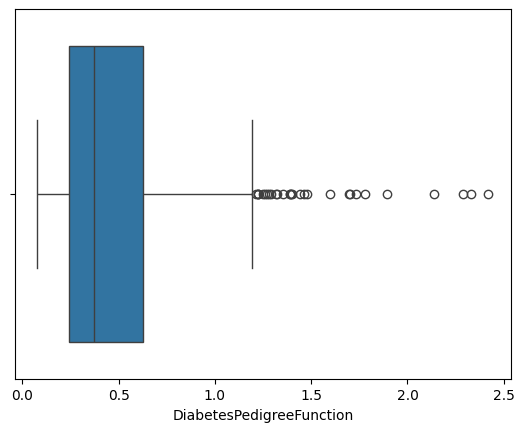

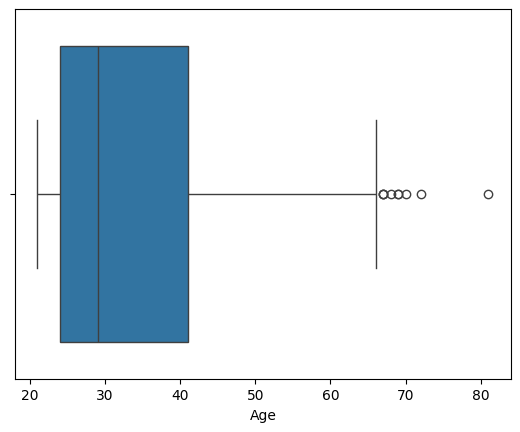

In [11]:
for column in X.columns:
    sns.boxplot(data = df, x = column)
    plt.show()

#### Outlier removal: for all feature outlier showing points are in real world are valid cause Pregnancies, Insulin, DPF, BMI, Glucose, BloodPressure, Age can increase suddenly or drop to low levels so removing those outliers can lead to loosing important information

### Handling missing values with median

In [12]:
# replacing 0 values with null cause fillna cannot remove 0
cols = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']
df[cols] = df[cols].replace(0, np.nan)

In [13]:
df[cols] = df[cols].fillna(df[cols].median())

In [14]:
df

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148.0,72.0,35.0,125.0,33.6,0.627,50,1
1,1,85.0,66.0,29.0,125.0,26.6,0.351,31,0
2,8,183.0,64.0,29.0,125.0,23.3,0.672,32,1
3,1,89.0,66.0,23.0,94.0,28.1,0.167,21,0
4,0,137.0,40.0,35.0,168.0,43.1,2.288,33,1
...,...,...,...,...,...,...,...,...,...
763,10,101.0,76.0,48.0,180.0,32.9,0.171,63,0
764,2,122.0,70.0,27.0,125.0,36.8,0.340,27,0
765,5,121.0,72.0,23.0,112.0,26.2,0.245,30,0
766,1,126.0,60.0,29.0,125.0,30.1,0.349,47,1


In [15]:
# chesking for missing values after replacing with median
(df[['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']] == 0).sum()

Glucose          0
BloodPressure    0
SkinThickness    0
Insulin          0
BMI              0
dtype: int64

### Dataset does nnot have any categorical feature so no encoding is required

In [16]:
# Assigning features a variable
X = df.drop('Outcome', axis = 1)
y = df['Outcome']

# Standardization
sc = StandardScaler()

# training scaled model
sc_x = sc.fit(X, y)
sc_x

,copy,True
,with_mean,True
,with_std,True


In [17]:
# Data splitting 
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

### Building XGB Model

In [18]:
#training model
xgb = XGBClassifier(n_estimators = 100, random_state = 42)
xgb.fit(X_train, y_train)

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [19]:
# prediction
y_pred_train = xgb.predict(X_train)
y_pred_test = xgb.predict(X_test)

### Model Evaluation

In [20]:
training_accuracy = accuracy_score(y_train, y_pred_train)
test_accuracy = accuracy_score(y_test, y_pred_test)
precision = precision_score(y_test, y_pred_test)
recall = recall_score(y_test, y_pred_test)
f1 = f1_score(y_test, y_pred_test)

print('Training Accuracy of XGB', training_accuracy)
print('Testing Accuracy of XGB', test_accuracy)
print('Precision score of XGB', precision)
print('Recall score  of XGB', recall)
print('F1-Score of XGB', f1)

Training Accuracy of XGB 1.0
Testing Accuracy of XGB 0.7142857142857143
Precision score of XGB 0.5873015873015873
Recall score  of XGB 0.6727272727272727
F1-Score of XGB 0.6271186440677966


### Hyper Parameter Tuning

In [38]:
# Assigning best parameter to reducee overfitting and improve accuracy
params_grid_xgb = {
    'n_estimators' : [200],
    'learning_rate' : [0.2],
    'max_depth' : [5],
    'min_child_weight' : [5],
    'gamma' : [0.5],
    'reg_lambda' : [10]
}

# creating gridsearch object
grid_search_xgb = GridSearchCV(
    xgb,
    params_grid_xgb, 
    cv = 5,
    scoring = 'accuracy'
)

#training model with gridsearch
grid_search_xgb.fit(X_train, y_train)

print(grid_search_xgb.best_params_) # gives best parametrs
print(grid_search_xgb.best_score_) # best cv score

best_xgb_model = grid_search_xgb.best_estimator_ # best model 
y_pred_train_xgb_best = best_xgb_model.predict(X_train)
best_training_accuarcy = accuracy_score(y_train, y_pred_train_xgb_best)
y_pred_test_xgb_best = best_xgb_model.predict(X_test)
best_test_accuarcy = accuracy_score(y_test, y_pred_test_xgb_best)

print('Training Accuracy', best_training_accuarcy)
print('Testing Accuracy', best_test_accuarcy)

{'gamma': 0.5, 'learning_rate': 0.2, 'max_depth': 5, 'min_child_weight': 5, 'n_estimators': 200, 'reg_lambda': 10}
0.7671064907370384
Training Accuracy 0.8843648208469055
Testing Accuracy 0.7532467532467533


#### Even after paramter tunning overfitting not reduced completely but many % of overfitting is reduced with best parameters

### Building LGBM Model

In [41]:
lgbm = LGBMClassifier(
    random_state=42,
    verbose = -1
)

#trains model 
lgbm.fit(X_train, y_train)

# prediction 
y_train_pred_lgbm = lgbm.predict(X_train)
y_test_pred_lgbm = lgbm.predict(X_test)

### Model Evaluation

In [42]:
traning_accuracy_lgbm = accuracy_score(y_train, y_train_pred_lgbm)
test_accuracy_lgbm = accuracy_score(y_test, y_test_pred_lgbm)
precision_lgbm = precision_score(y_test, y_test_pred_lgbm)
recall_lgbm = recall_score(y_test, y_test_pred_lgbm)
f1_lgbm = f1_score(y_test, y_test_pred_lgbm)

print('Training Accuracy', traning_accuracy_lgbm)
print('Testing Accuracy', test_accuracy_lgbm)
print('Precision score', precision_lgbm)
print('Recall score', recall_lgbm)
print('F1-Score', f1_lgbm)

Training Accuracy 1.0
Testing Accuracy 0.7207792207792207
Precision score 0.6
Recall score 0.6545454545454545
F1-Score 0.6260869565217392


### Hyper Parameter Tunning

In [31]:
param_grid = {
    'n_estimators':[100,200],
    'max_depth':[3,5,7],
    'learning_rate':[0.01,0.1]
}

grid_lgbm = GridSearchCV(
    lgbm,
    param_grid,
    cv=5,
    scoring='accuracy'
)

grid_lgbm.fit(X_train,y_train)

print(grid_lgbm.best_params_)
print(grid_lgbm.best_score_)

best_lgbm_model = grid_lgbm.best_estimator_
y_pred_train_lgbm_best = best_lgbm_model.predict(X_train)
best_training_accuarcy_lgbm = accuracy_score(y_train, y_pred_train_lgbm_best)
y_pred_test_lgbm_best = best_lgbm_model.predict(X_test)
best_test_accuarcy_lgbm = accuracy_score(y_test, y_pred_test_lgbm_best)

print('Training Accuracy', best_training_accuarcy_lgbm)
print('Testing Accuracy', best_test_accuarcy_lgbm)


{'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 100}
0.7687458349993337
Training Accuracy 0.8957654723127035
Testing Accuracy 0.7532467532467533


#### Even after paramter tunning overfitting not reduced completely but many % of overfitting is reduced with best parameters

### Comparitive analysis

In [34]:
print("XGBoost Model Accuracy", best_test_accuarcy) # for XGBoost
print("LGBM Model Accuracy", best_test_accuarcy_lgbm) # for LGBM

XGBoost Model Accuracy 0.7467532467532467
LGBM Model Accuracy 0.7532467532467533


#### Both model performed almost same but LGBM model performed slight better than XGBoost

### Visaulization

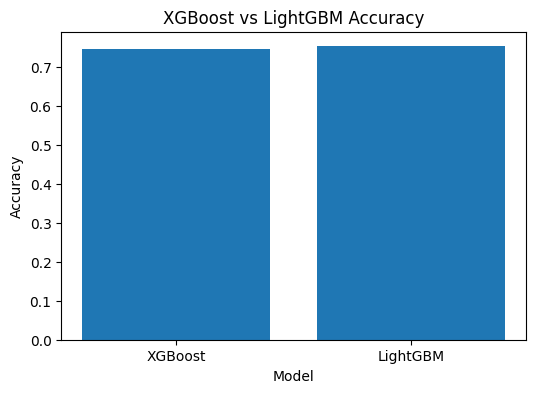

In [37]:
models = ["XGBoost", "LightGBM"]
accuracies = [best_test_accuarcy, best_test_accuarcy_lgbm]

plt.figure(figsize=(6,4))
plt.bar(models, accuracies)

plt.title("XGBoost vs LightGBM Accuracy")
plt.xlabel("Model")
plt.ylabel("Accuracy")

plt.show()

##### A comparison of the test accuracies shows that LightGBM achieved an accuracy of 75.32%, while XGBoost achieved 74.68%. The performance difference between the two models is small, indicating that both algorithms are effective for this classification task.

Strengths of XGBoost: 
1. Strong predictive performance due to advanced boosting techniques.
2. Includes regularization mechanisms that help reduce overfitting.

Weaknesses of XGBoost: 
1. Training time is generally longer than LightGBM.
2. Consumes more computational resources and memory.
   
Strengths of LightGBM
1. Faster training and prediction speed.
2. Achieved the highest accuracy in this experiment.
   
Weaknesses of LightGBM
1. Can be more sensitive to hyperparameter settings.
2. May overfit if not properly tuned.